### General Monte Carlo algorithm for estimating the area of arbitrary 2D regions.

Monte Carlo methods give an intuitive way of approximating answers to problems where exact solutions are often too complex or impossible to calculate analytically.

In [266]:
import numpy as np
from numpy import random
import matplotlib.pyplot as plt
from scipy.integrate import quad

In [267]:
sample_number = 10000

x_range = [0, 20]

rng = np.random.default_rng(10)

In [268]:
#example functions

def func(x):
    return sin(x) + 0.05*x**2

In [269]:
# Find maximum y value in the range
def y_max_calc(x_range, integrand):
    x_values = np.linspace(x_range[0], x_range[1], 10000)
    y_values = integrand(x_values)
    y_max = np.max(y_values)

    headroom = 1.1
    y_max *= headroom 
    return y_max

def monteCarloSim(sample_number, x_range, y_max, integrand, plot=True):  

    # Generate all random samples at once
    x_samples = rng.uniform(x_range[0], x_range[1], sample_number)
    y_samples = rng.uniform(0, y_max, sample_number)

    # Determine which points lie below the curve
    inside = y_samples <= integrand(x_samples)

    # Estimate integral
    area = y_max * abs(x_range[1] - x_range[0])
    integral = area * np.mean(inside)

    if plot:
        colours = np.where(inside, "blue", "red")

        fig, ax = plt.subplots(figsize=(8, 8))

        ax.scatter(
            x_samples,
            y_samples,
            s=2,
            color=colours,
            alpha=0.2
        )

        ax.set_xlabel("x axis")
        ax.set_ylabel("y axis")

        plt.show()

    return integral

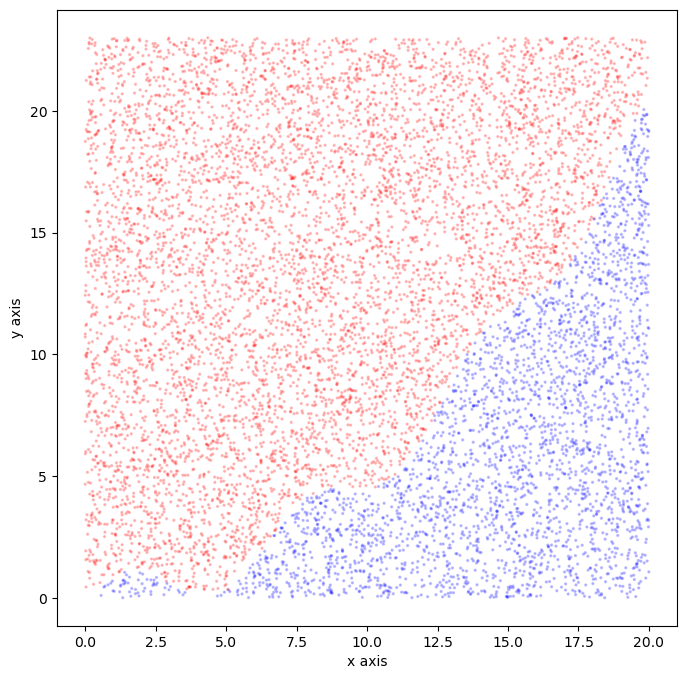

In [270]:
y_max = y_max_calc(x_range, func)
y = monteCarloSim(sample_number, x_range, y_max, func)

In [271]:
def error_calc (sample_number, x_range, integrand, info=False):
    
    I, quad_error = quad(integrand, x_range[0], x_range[1])
    
    I_est = monteCarloSim(
        sample_number, 
        x_range, 
        y_max, 
        integrand, 
        plot=False
    )
    
    error = abs(I - I_est)

    if info:
        print(f"To 2dp, the integral result to 2dp is: {I:.2f}")
        print(f"The Monte Carlo method using {sample_number} samples obtained a value of: {I_est:.2f}")
        print(f"The error on this result is {error:.2f}. As a percentage: {100*error/I:.2f}%")
        return
        
    return error

In [272]:
error_calc(sample_number, x_range, func, info=True)

To 2dp, the integral result to 2dp is: 133.93
The Monte Carlo method using 10000 samples obtained a value of: 130.48
The error on this result is 3.45. As a percentage: 2.57%


In [282]:
def error_sample_analysis(sample_numbers, x_range, integrand):
    mean_errors = []
    std_errors = []
    for sample in sample_numbers:
        errors = []
        for _ in range (500): 
            errors.append(error_calc(sample, x_range, integrand))
        mean_errors.append(np.mean(errors))
        std_errors.append(np.std(errors))

    log_samples = np.log(sample_numbers)
    log_errors = np.log(mean_errors)

    gradient, intercept = np.polyfit(log_samples, log_errors, 1)
    
    fig, ax = plt.subplots()
    ax.plot(
        sample_numbers, 
        mean_errors, 
        label = f"gradient = {gradient:.3f}"
    )

    ax.errorbar(sample_numbers, mean_errors, yerr=std_errors, fmt='o')
    
    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel("Number of samples")
    ax.set_ylabel("Mean absolute error")

    ax.legend()

    return

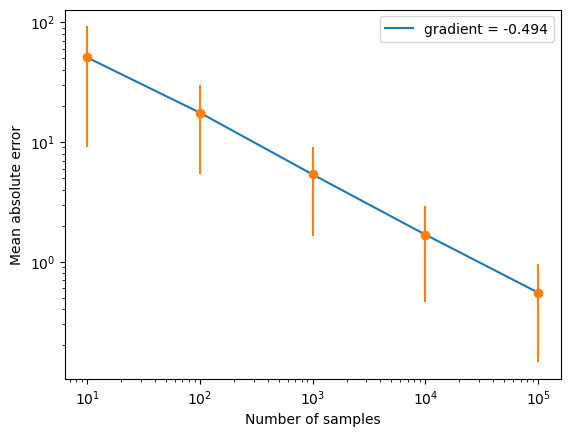

In [283]:
sample_numbers = [10, 100, 1000, 10000, 100000]
error_sample_analysis(sample_numbers, x_range, func)

The gradient of the plot above agrees with the theoretical $N^{-1/2}$ relationship